In [2]:
# figure 1. for paper
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../src')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../src/utils')))
import xarray as xr
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
import scipy.io as scio
from tools import add_patch_missing, add_point_missing
import h5py

## navier-stocks

In [2]:
data_dir = "/data/jingren/repository/dataset/PDE_datasets/NavierStokes_V1e-5_N1200_T20.mat"
num_train = 1000
num_test  = 200
T_all     = 20
missing_rate = 0.5
data      = scio.loadmat(data_dir)['u']
train_au  = torch.tensor(data[:num_train,   ::1, ::1, :T_all], dtype=torch.float).reshape(num_train, -1, T_all)
test_au   = torch.tensor(data[-num_test:,   ::1, ::1, :T_all], dtype=torch.float).reshape(num_test,  -1, T_all)

In [ ]:
from tools import add_patch_missing
test_au, test_mask = add_patch_missing(test_au, missing_rate=missing_rate, space_size=[64, 64], patch_size=4)

<Figure size 640x480 with 0 Axes>

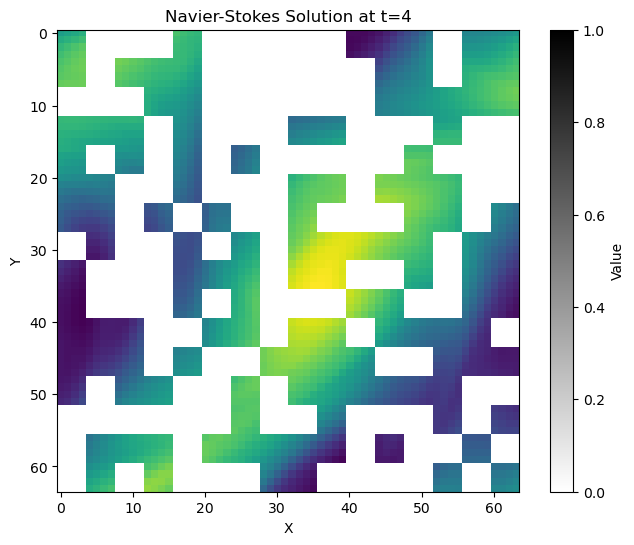

In [9]:
plt.clf()
# Select a specific time step (e.g., t=0)
t =4
# Reshape the data back to 64x64 spatial grid
plot_data = test_au[0, :, t].reshape(64, 64)
mask = test_mask[0, :, t].reshape(64, 64)

# Create the plot
plt.figure(figsize=(8, 6))

# First plot the full data
plt.imshow(plot_data, cmap='viridis')

# Then overlay black color for masked regions
plt.imshow(np.where(mask == 0, 0, np.inf), cmap='binary', alpha=1, vmin=0, vmax=1)

plt.colorbar(label='Value')
plt.title(f'Navier-Stokes Solution at t={t}')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

## diffusion

In [3]:
space_size = [128, 128]
H, W = space_size[0], space_size[1]
data_dir = "/data/jingren/repository/dataset/PDEBench/2D/diffusion-reaction/2D_diff-react_NA_NA.h5"
downsample = 2
num_train = 1000
num_test  = 200
T_all     = 20
missing_rate = 0.5
with h5py.File(data_dir, 'r') as f:
    keys = list(f.keys())
    keys.sort()
    data_arrays = [
        np.array(f[key]["data"], dtype=np.float32) for key in keys
    ]
    _data = torch.from_numpy(
        np.stack(data_arrays, axis=0)
    )  # [B, nt, nx, ny, nc]
    B, T, H, W, C = _data.shape
    _data = _data[..., 0].permute(0, 2, 3, 1).reshape(B, H, W, T)  # for activator
    _data = _data[..., 50:]
    train_xy = _data[:num_train, ::downsample, ::downsample, ::2][..., :T_all]
    test_xy  = _data[-num_test:, ::downsample, ::downsample, ::2][..., :T_all]
train_xy = train_xy.reshape(num_train, -1, T_all)
test_xy  = test_xy. reshape(num_test,  -1, T_all)

In [9]:
from tools import add_patch_missing
#test_xy_, test_mask = add_patch_missing(test_xy, missing_rate=0.5, space_size=[64,64], patch_size=4)
test_xy_, test_mask = add_point_missing(test_xy, num_sampling=2048)

<Figure size 640x480 with 0 Axes>

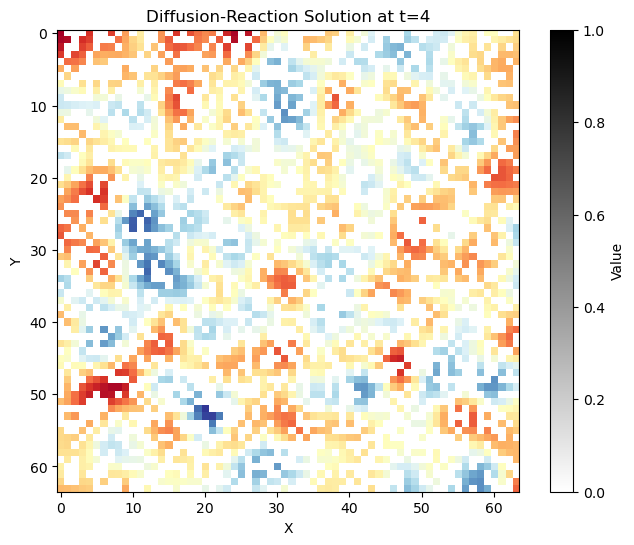

In [13]:
plt.clf()
# Select a specific time step (e.g., t=0)
t = 4

# Reshape the data back to 64x64 spatial grid
plot_data = test_xy_[0, :, t].reshape(64, 64)
mask      = test_mask[0, :, t].reshape(64, 64)

# Create the plot
plt.figure(figsize=(8, 6))

# First plot the full data
plt.imshow(plot_data, cmap='RdYlBu')

# Then overlay black color for masked regions
plt.imshow(np.where(mask == 0, 0, np.inf), cmap='binary', alpha=1, vmin=0, vmax=1)

plt.colorbar(label='Value')
plt.title(f'Diffusion-Reaction Solution at t={t}')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

## ERA5

In [30]:
space_size = [720, 1440]
downsample = 8
data_dir = "/data/jingren/repository/dataset/WeatherBench/2m_temperature_18-25.grib"
H, W = space_size[0], space_size[1]
# load_data
ds = xr.open_dataset(data_dir)
data = torch.tensor(np.array(ds["t2m"]))
h = int((H / downsample))
w = int((W / downsample))
Tn = 7 * int(data.shape[0] / 7)
missing_rate = 0.2
data = data[:, :720, :]
data = data[:, ::downsample, ::downsample]
data = data[::200, ...].permute(1, 2, 0).reshape(h*w, -1)
data_missing, mask = add_patch_missing(data.unsqueeze(dim=0), missing_rate, (h, w), patch_size=6)
data = data.reshape(1, h, w, -1)
data_missing  = data_missing.reshape(1, h, w, -1)

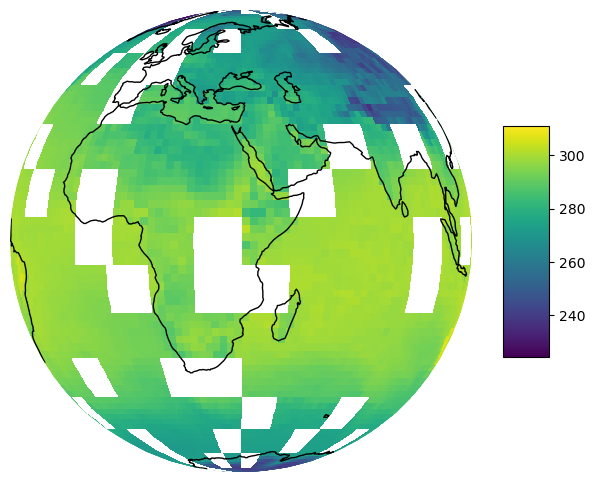

In [44]:
# ...在plt_era5_3D函数最后添加...
from matplotlib.patches import Circle

plot_data = data[0, :, :, 0]
mask = data_missing[0, :, :, 0]  # Assuming you want to plot the first time step
data
def plt_era5_3D(data0, mask0):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(0, 0))
    ax.coastlines()
    lon = np.linspace(0, 360, 180)
    lat = np.linspace(90, -90, 90)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    mesh = ax.pcolormesh(lon_grid, lat_grid, data0, cmap=cm.viridis, transform=ccrs.PlateCarree())
    mesh1 = ax.pcolormesh(lon_grid, lat_grid, np.where(mask0 == 0, 0, np.inf), cmap=cm.binary, alpha=1, vmin=0, vmax=1, transform=ccrs.PlateCarree())
    ax.projection = ccrs.Orthographic(central_longitude=35, central_latitude=0)
    fig.colorbar(mesh, ax=ax, shrink=0.5, aspect=5)
    ax.set_axis_off()

    # 添加地球外圈粗边
    #circle = Circle((0, 0), 1.01, transform=ax.transAxes, fill=False, color='black', linewidth=8, zorder=10)
    #ax.add_patch(circle)

plt_era5_3D(plot_data.numpy(), mask.numpy())

## 1-3 with mask

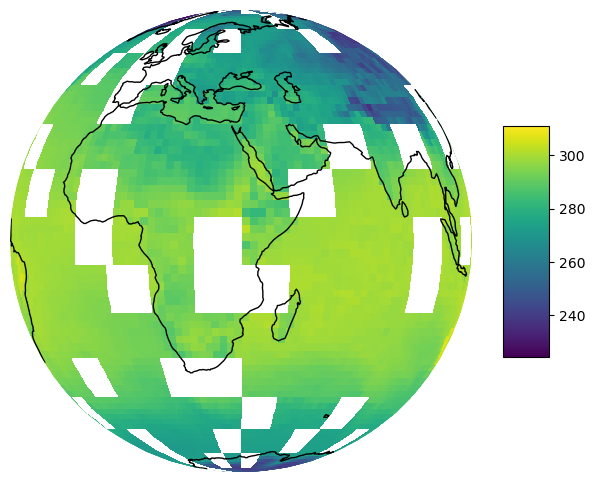

In [34]:
plt_era5_3D(
    data[0, :, :, 0].numpy(),
    data_missing[0, :, :, 0].numpy()
)

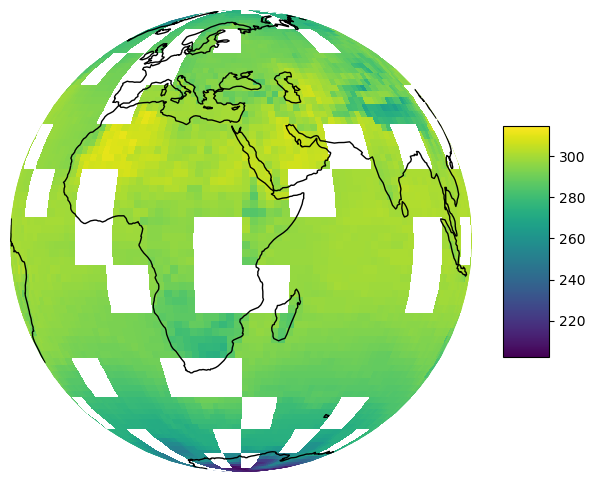

In [35]:
plt_era5_3D(
    data[0, :, :, 1].numpy(),
    data_missing[0, :, :, 1].numpy()
)

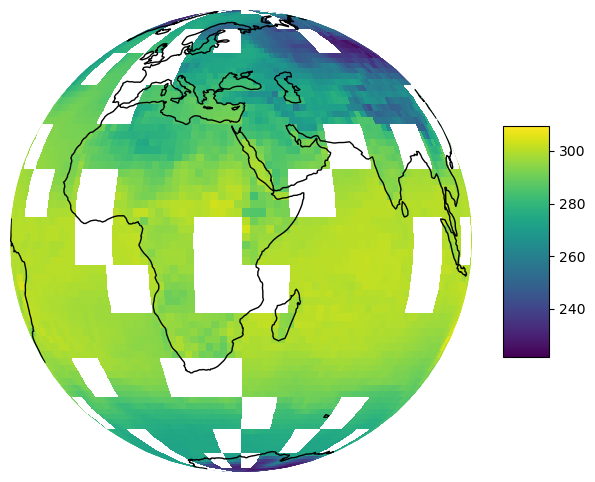

In [36]:
plt_era5_3D(
    data[0, :, :, 2].numpy(),
    data_missing[0, :, :, 2].numpy()
)

## 4-6 masked

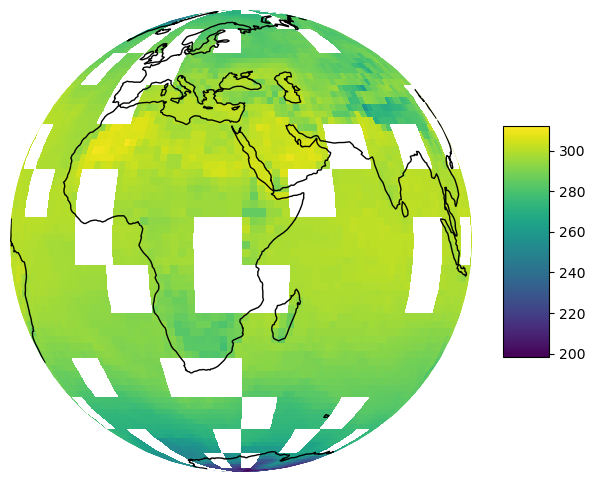

In [37]:
plt_era5_3D(
    data[0, :, :, 3].numpy(),
    data_missing[0, :, :, 3].numpy()
)

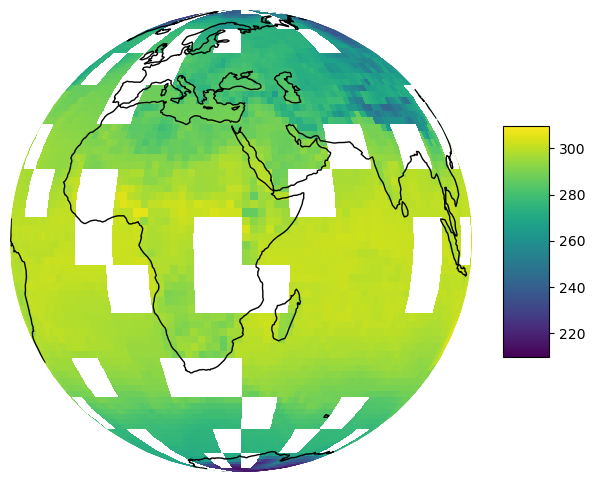

In [38]:
plt_era5_3D(
    data[0, :, :, 4].numpy(),
    data_missing[0, :, :, 4].numpy()
)

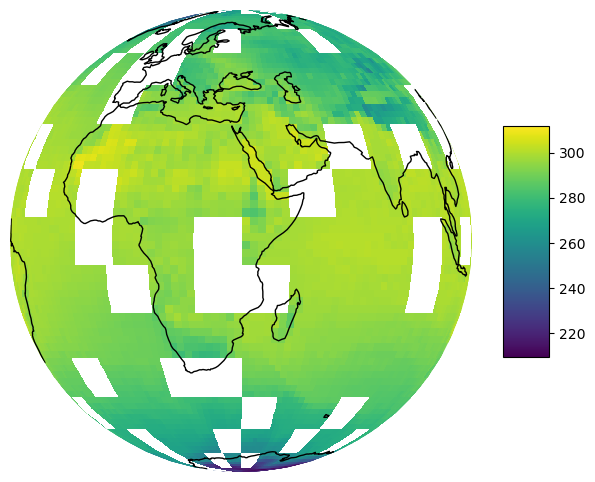

In [39]:
plt_era5_3D(
    data[0, :, :, 5].numpy(),
    data_missing[0, :, :, 5].numpy()
)

## 7-9 masked

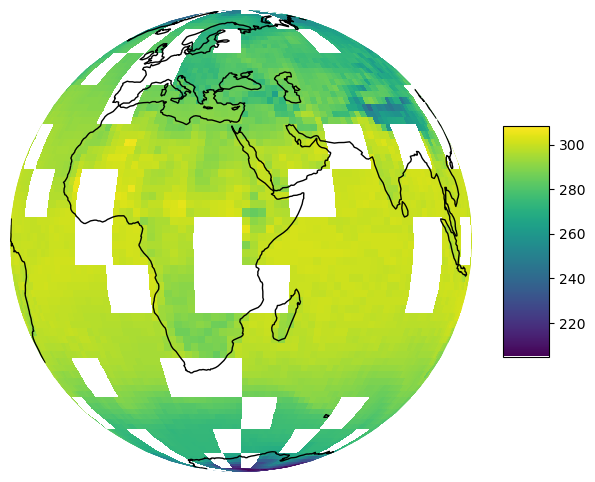

In [45]:
plt_era5_3D(
    data[0, :, :, 6].numpy(),
    data_missing[0, :, :, 6].numpy()
)

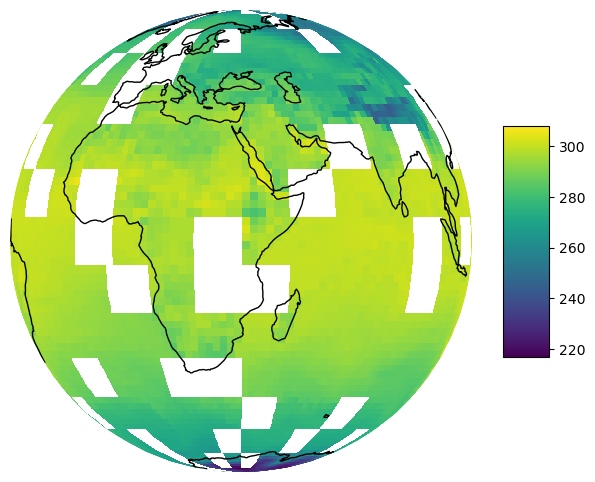

In [46]:
plt_era5_3D(
    data[0, :, :, 7].numpy(),
    data_missing[0, :, :, 7].numpy()
)

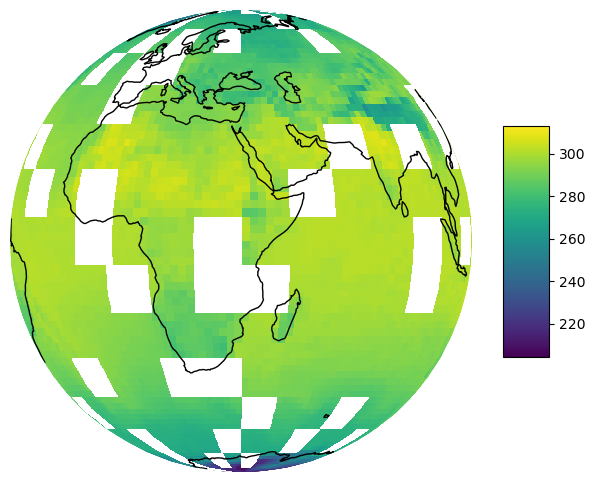

In [47]:
plt_era5_3D(
    data[0, :, :, 8].numpy(),
    data_missing[0, :, :, 8].numpy()
)

## 10-12 unmasked

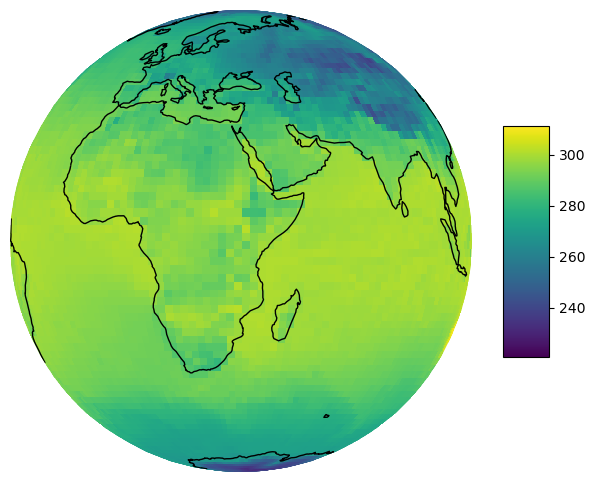

In [49]:
plt_era5_3D(
    data[0, :, :, 9].numpy(),
    torch.ones_like(data[0, :, :, 0]).numpy()
)

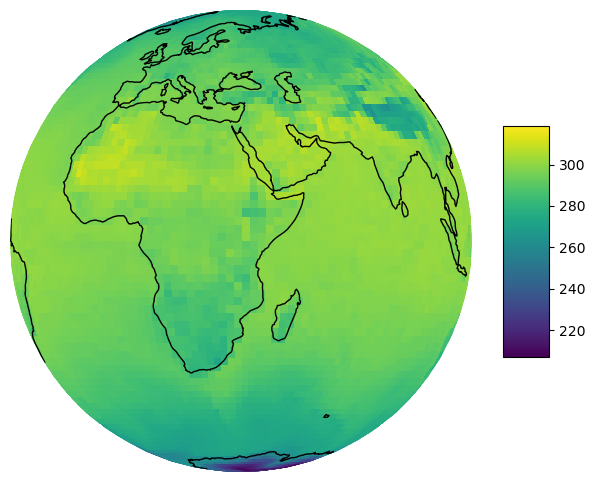

In [50]:
plt_era5_3D(
    data[0, :, :, 10].numpy(),
    torch.ones_like(data[0, :, :, 0]).numpy()
)

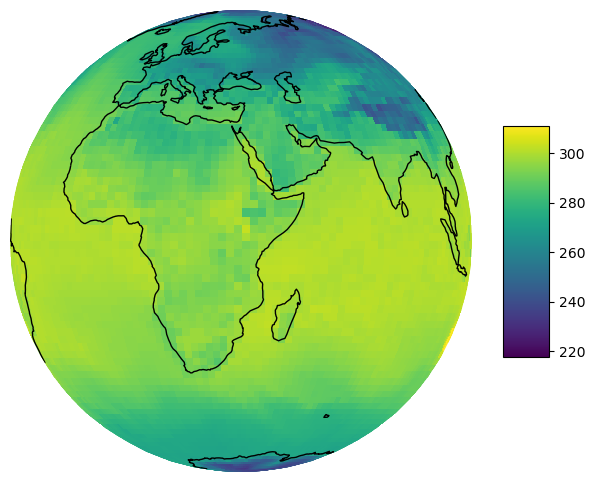

In [51]:
plt_era5_3D(
    data[0, :, :, 11].numpy(),
    torch.ones_like(data[0, :, :, 0]).numpy()
)

In [ ]:
data_mask_dir = "/data/jingren/repository/dataset/HadCRUT_5/1_to_10_netcdf/HadCRUT.5.0.2.0.anomalies.1.nc"
ds = xr.open_dataset(data_mask_dir) 
temp = torch.tensor(ds["tas"].values)
mask = ~torch.isnan(temp)
B = mask.shape[0]
mask = mask[B-num_train-num_test:, ...].float()
train_mask = mask[:num_train, :, :].reshape(num_train, -1, 1).repeat(1, 1, 14)
test_mask  = mask[:num_test,  :, :].reshape(num_test,  -1, 1).repeat(1, 1, 14)
# train
train_x = train_xy[...,  :7] * train_mask[...,  :7]
train_y = train_xy[..., 7: ] * train_mask[..., 7: ]
# test
test_x  = test_xy[...,  :7] * test_mask[...,  :7]
test_y  = test_xy[..., 7: ]
# test high
test_mask_high = test_mask
test_x_high = test_x

36.0

In [33]:
1440/20

72.0